## Importing libraries

In [140]:
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

In [141]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

In [142]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout

In [143]:
import joblib

## Data Preprocessing

In [144]:
dataset = pd.read_csv("./data/raw/Crop_recommendation.csv")

In [145]:
dataset.head(2)

,Nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,label,Unnamed: 8,Unnamed: 9
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,NaN,NaN
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,NaN,NaN


In [146]:
dataset.drop(["Unnamed: 8", "Unnamed: 9", "rainfall"], axis=1, inplace=True)

In [147]:
dataset.isnull().sum()

,0
Nitrogen,0
phosphorus,0
potassium,0
temperature,0
humidity,0
ph,0
label,0


In [148]:
dataset.describe()

,Nitrogen,phosphorus,potassium,temperature,humidity,ph
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091


In [149]:
features = dataset.drop(["label", "potassium"], axis=1)
features.head(2)

,Nitrogen,phosphorus,temperature,humidity,ph
0,90,42,20.879744,82.002744,6.502985
1,85,58,21.770462,80.319644,7.038096


In [150]:
labels = dataset["label"]

In [151]:
labelEncoder = LabelEncoder()

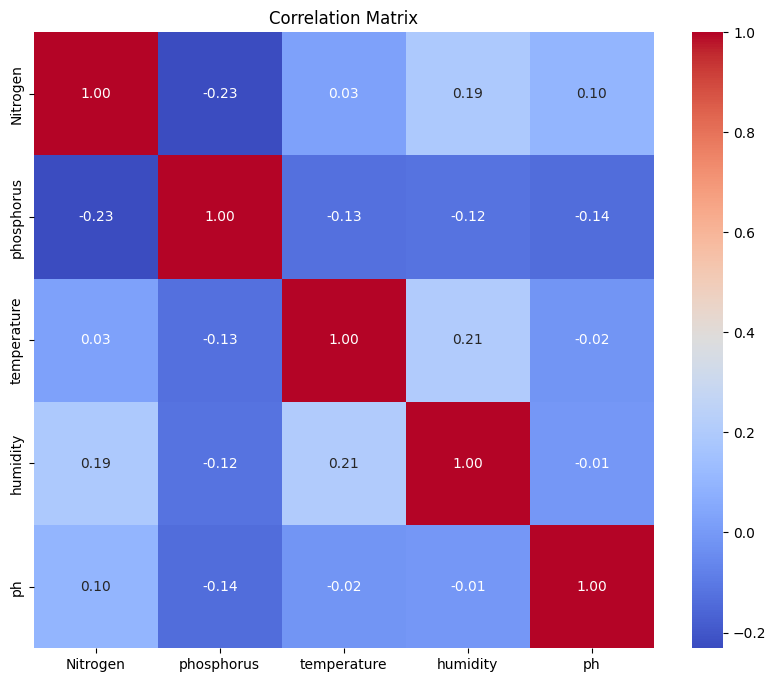

In [152]:
correlation_matrix = features.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [153]:
print(f"Number of crops in non time series dataset: {len(labels.unique())}")

Number of crops in non time series dataset: 22


In [154]:
# features["temperature"] = features["temperature"]/features["temperature"].max()
# features["humidity"] = features["humidity"]/features["humidity"].max()
# features["ph"] = features["ph"]/features["ph"].max()
# features["rainfall"] = features["rainfall"]/features["rainfall"].max()

In [155]:
features.head(2)

,Nitrogen,phosphorus,temperature,humidity,ph
0,90,42,20.879744,82.002744,6.502985
1,85,58,21.770462,80.319644,7.038096


In [156]:
labels = labelEncoder.fit_transform(labels)

In [157]:
labels

array([20, 20, 20, ...,  5,  5,  5])

In [158]:
labelEncoder.inverse_transform([2])

array(['blackgram'], dtype=object)

In [160]:
joblib.dump(labelEncoder, './encoders/crp_label_encoder.pkl')

['./encoders/crp_label_encoder.pkl']

## Feature Scaling

In [161]:
sc = MinMaxScaler(feature_range= (0, 1))

In [162]:
features = features.to_numpy()
features = sc.fit_transform(features)
joblib.dump(sc, './scalers/crp_scaler_ann.pkl')

['./scalers/crp_scaler_ann.pkl']

In [163]:
x_train, x_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, stratify=labels, random_state=42
)

In [164]:
stratified_kfold = StratifiedKFold(n_splits=3)

## Model Training

In [132]:
model = Sequential([
    Dense(16, activation="relu"),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(22, activation="softmax")
])

In [133]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),loss=tf.keras.losses.sparse_categorical_crossentropy, metrics=["accuracy"])

Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1263 - loss: 2.9343 - val_accuracy: 0.4906 - val_loss: 1.8051
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4006 - loss: 1.7110 - val_accuracy: 0.5928 - val_loss: 1.1106
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5333 - loss: 1.1851 - val_accuracy: 0.6201 - val_loss: 0.9160
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5607 - loss: 1.0721 - val_accuracy: 0.7104 - val_loss: 0.7667
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6187 - loss: 0.9434 - val_accuracy: 0.7683 - val_loss: 0.6876
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6283 - loss: 0.9176 - val_accuracy: 0.7581 - val_loss: 0.6295
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6565 - loss: 0.8314 - val_accuracy: 0.7871 - val_loss: 0.5608
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6652 - loss: 0.7931 - val_accuracy: 0.7785 - v

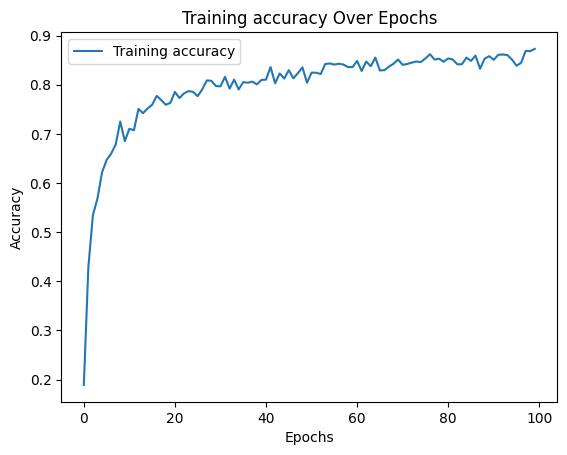

In [134]:
history = None
for train_index, val_index in stratified_kfold.split(x_train, y_train):
    x_train_fold, x_val = x_train[train_index], x_train[val_index]
    y_train_fold, y_val = y_train[train_index], y_train[val_index]

    # Model Training
    # If condition is just for showing the accuracy graph
    if(not history):
      history = model.fit(x_train, y_train,
                      epochs=100,
                      validation_data=(x_val, y_val))
      plt.plot(history.history['accuracy'], label='Training accuracy')
      plt.xlabel('Epochs')
      plt.ylabel('Accuracy')
      plt.title('Training accuracy Over Epochs')
      plt.legend()
    else:
      history = model.fit(x_train, y_train,
                    epochs=100,
                    validation_data=(x_val, y_val))
    model.optimizer.learning_rate = 0.001
    history = model.fit(x_train, y_train,
                    epochs=100,
                    validation_data=(x_val, y_val))
    # Evaluating on Validation set
    y_pred = model.predict(x_val)
    loss, accuracy = model.evaluate(x_val, y_val)
    print(f"Accuracy: {accuracy}")
    print(f"Loss: {loss}")

In [135]:
test_loss, test_accuracy = model.evaluate(x_train, y_train)

print(f'Training loss: {test_loss:.4f}')
print(f'Training Accuracy: {test_accuracy:.4f}')

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9359 - loss: 0.1541
Training loss: 0.1434
Training Accuracy: 0.9403


In [136]:
test_loss, test_accuracy = model.evaluate(x_val, y_val)

print(f'Validation loss: {test_loss:.4f}')
print(f'Validation Accuracy: {test_accuracy:.4f}')

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9365 - loss: 0.1528 
Validation loss: 0.1392
Validation Accuracy: 0.9386


In [137]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print(f'Test loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9163 - loss: 0.1835 
Test loss: 0.1832
Test Accuracy: 0.9250


In [138]:
model.save("./models/crpann.keras")